
=== TABLA MAESTRA ===

  Pais         Grupo  R2_corr_CA  R3_corr_TB  R4_corr_I  R5_vol_ratio  \
0  USA  Desarrollado      -0.232      -0.212      0.530         0.796   
1  DEU  Desarrollado      -0.022      -0.008      0.270         1.637   
2  CHN     Emergente       0.082       0.104      0.123         0.916   
3  PER     Emergente      -0.249      -0.058      0.444         0.665   
4  CHL     Emergente      -0.306      -0.271      0.501         0.707   
5  KOR     Emergente      -0.627      -0.642      0.396         1.773   
6  TUR     Emergente      -0.393      -0.461      0.399         0.966   

   R6_corr_SI  
0       0.687  
1      -0.265  
2       0.838  
3       0.564  
4       0.124  
5       0.612  
6       0.810  


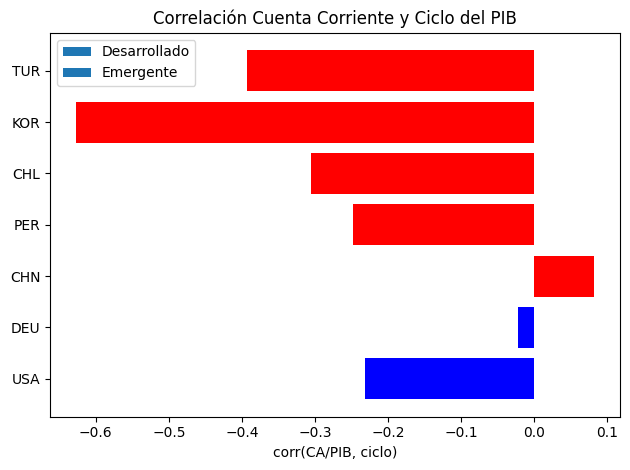

In [1]:
# Item 22

!pip install wbgapi statsmodels pandas matplotlib -q

import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.filters.hp_filter import hpfilter

#Indicadores WDI
indicators = {
    'NY.GDP.MKTP.KD': 'gdp_real',
    'BN.CAB.XOKA.GD.ZS': 'ca_gdp',
    'NE.RSB.GNFS.ZS': 'tb_gdp',
    'NE.GDI.TOTL.ZS': 'inv_gdp',
    'NY.GNS.ICTR.ZS': 'sav_gdp',
    'NE.CON.TOTL.ZS': 'cons_gdp',
}

#Paises
countries = {
    'USA': 'Desarrollado',
    'DEU': 'Desarrollado',
    'CHN': 'Emergente',
    'PER': 'Emergente',
    'CHL': 'Emergente',
    'KOR': 'Emergente',
    'TUR': 'Emergente'
}

results = []

#Loop x pais
for country, group in countries.items():

    raw = wb.data.DataFrame(
        list(indicators.keys()),
        economy=country,
        time=range(1990, 2024)
    )

    df = raw.T
    df.columns = [indicators[c] for c in raw.index]
    df.index = [int(str(i).replace('YR', '')) for i in df.index]
    df = df.sort_index().astype(float)

    #Filtro HP
    df_clean = df['gdp_real'].dropna()
    cycle, trend = hpfilter(np.log(df_clean), lamb=6.25)
    df['gdp_cycle'] = cycle.reindex(df.index)

    #Estadisticos
    corr_CA = df['gdp_cycle'].corr(df['ca_gdp'])
    corr_TB = df['gdp_cycle'].corr(df['tb_gdp'])
    corr_I = df['gdp_cycle'].corr(df['inv_gdp'])
    vol_ratio = df['inv_gdp'].std() / df['cons_gdp'].std()
    corr_SI = df['sav_gdp'].corr(df['inv_gdp'])

    results.append({
        'Pais': country,
        'Grupo': group,
        'R2_corr_CA': corr_CA,
        'R3_corr_TB': corr_TB,
        'R4_corr_I': corr_I,
        'R5_vol_ratio': vol_ratio,
        'R6_corr_SI': corr_SI
    })

#Tabla general o maestra
master_table = pd.DataFrame(results)

print("\n=== TABLA MAESTRA ===\n")
print(master_table.round(3))

#Guardar CSV
master_table.to_csv("tabla_maestra.csv", index=False)


#Grafico de barras horizontales (R2)

#Colores por grupo
colors = master_table['Grupo'].map({
    'Desarrollado': 'blue',
    'Emergente': 'red'
})

plt.figure()
plt.barh(master_table['Pais'], master_table['R2_corr_CA'], color=colors)

plt.xlabel('corr(CA/PIB, ciclo)')
plt.title('Correlación Cuenta Corriente y Ciclo del PIB')

#Leyenda
for label, color in [('Desarrollado', 'blue'), ('Emergente', 'red')]:
    plt.barh([], [], color=color, label=label)

plt.legend()
plt.tight_layout()
plt.show()


#Item 23

#(a)
#R2 se cumple en todos los países menos China, pues este último
#tiene una corr con CA positiva (+0.082).

#El promedio (en valor absoluto) de R2 en economías desarrolladas
#es de 0.127, mientras
#que en emergentes es 0.331. Esto confirma que la CA es más cotracíclica
#en economías emergentes.

#Si se puede ver un patrón, en las economías emergentes, la mayor
#contraciclidad en la CA indica que la inversión es la referente en los ajustes
#ante shocks. En cambio, en economías desarrolladas se muestra un suavizamiento
#del consumo. Esto hace sentido pues las economías desarrolladas tienen un
#mejor acceso a los sistemas financieros internacionales, que permite tener
#un endeudamiento prolongado.


#(b)
#R6 no se cumple para Alemania (tiene un valor -0.265). Chile tiene un R6 positivo
#pero bastante bajo.

#Cuando S-I es bajo, el ahorro doméstico y la inversión no se vinculan
#fuertemente. Esto significa que el país puede ahorrar en el exterior o
#financiar su inversión con capital del exterior. Por lo tanto, el valor bajo
#de S-I si sugiere que el país esté más integrado en el sistema financiero
#internacional (y mayoe movilidad de capitales).


#(c)
#R5 falla para Alemania (1.637) y Corea (1.773), eso indica que la inversión
#es más volatil que el consumo. En los demás países se da el caso contrario.
#Las economías que muestran el comportamiento más volatil en el consumo suelen
#ser emergentes (es curioso que esté EE.UU.), pues estas presentan mayores
#problemas para suavizar el consumo, puede ser por el limitado acceso al
#crédito, y su sensibilidad es mayor ante shocks.

#El primer país que no coincide con la teoría inicial es EE.UU., esto puede
#deberse a lo relevante que es dólar a nivel mundial como moneda de reserva.
#Esta gran demanda por la moneda da un buen espacio a EE.UU. para financiar
#sus desequlibrios externos facilmente.

#El segundo país que no coincide con la teoría es Chile. Este país usa sus
#fondos soberanos para obtener una política contracíclica y suavizar la
#inversión pública. Además, es un país afectado por los shocks de
#términos de intercambio (precio del cobre mayormente), esto hace que el ingreso
#nacional tenga una mayor fluctuación y el conusumo sea impactado.



